In [30]:
import numpy as np
import matplotlib.pyplot as plt
import math

from metashapes.library import rectangle, ellipse, ngon, cross, ring
from metashapes.canvas import Canvas
from metashapes.shape import Shape
from metashapes.utils import to_wkt, scale

import shapely
import shapely.affinity as A

In [2]:
#Create canvas
Lx = 300
Ly = 300
H = 300
W = 300

canv = Canvas(-Lx/2, -Ly/2, Lx, Ly, H, W)

print(f'dx: {canv.dx}')
print(f'dy: {canv.dy}')
print(f'H: {canv.H}')
print(f'W: {canv.W}')

with canv.temporary_pixel_size(0.5):
    print(f'dx: {canv.dx}')
    print(f'dy: {canv.dy}')
    print(f'H: {canv.H}')
    print(f'W: {canv.W}')

print(f'dx: {canv.dx}')
print(f'dy: {canv.dy}')
print(f'H: {canv.H}')
print(f'W: {canv.W}')

dx: 1.0
dy: 1.0
H: 300
W: 300
dx: 0.5
dy: 0.5
H: 600
W: 600
dx: 1.0
dy: 1.0
H: 300
W: 300


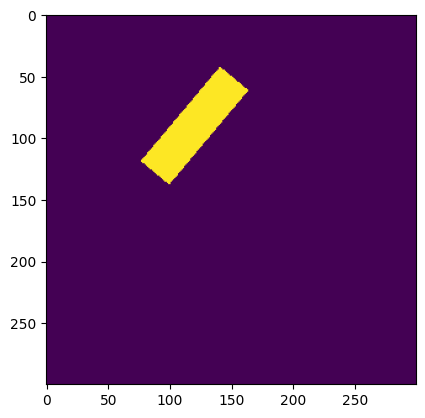

In [3]:
rect = rectangle((-30, 60), (100, 30), angle=50)
plt.imshow(rect.to_numpy(canv))

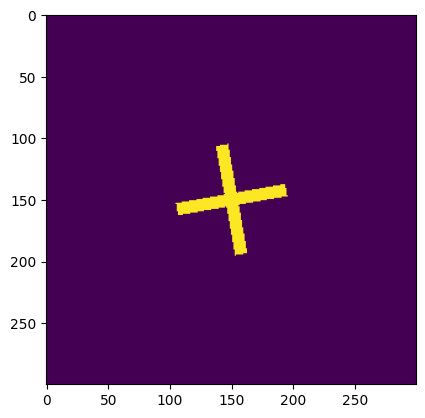

In [4]:
cross1 = cross((0, 0), 90, 10, angle = 10)
plt.imshow(cross1.to_numpy(canv))

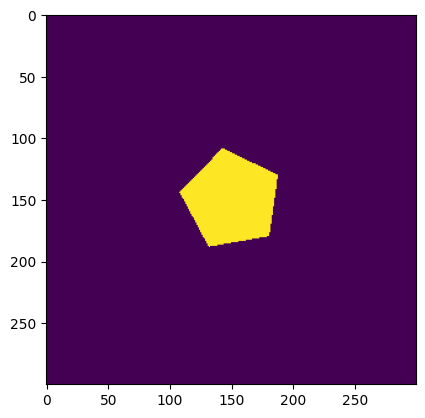

In [5]:
tri = ngon((0, 0), 50, 5, angle=10)
plt.imshow(tri.to_numpy(canv))

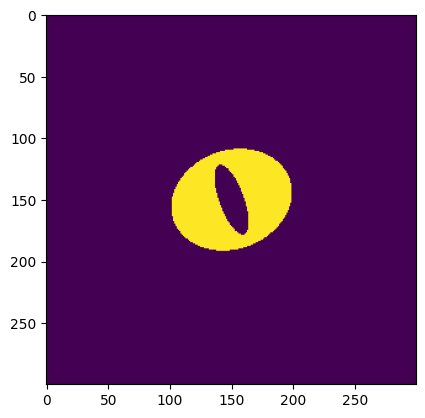

In [6]:
r = ring((0, 0), (50, 40), (10, 30), angle=10.0)
plt.imshow(r.to_numpy(canv))

Image reconstruction error: 0.005216 (0 = perfect, 1 = total mismatch)


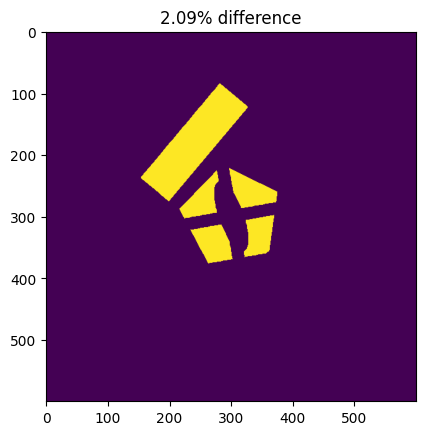

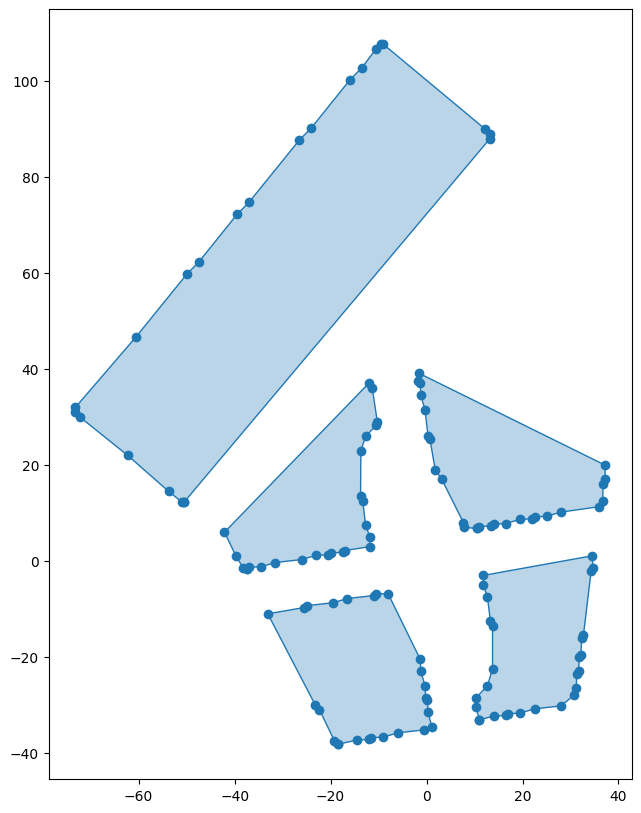

In [33]:
canv_new = canv
canv_new.set_grid(600, 600)
shape = ((r.difference(cross1)).intersection(tri)).union(rect)

shape2 = Shape.from_numpy(shape.to_numpy(canv), 
                          canv, 
                          simp_coeff=0.5,
                          sfd=False,
                          gaussian=True,
                          gauss_sigma=0.6,
                          verbose=True)


diff = (shape.to_numpy(canv).astype(float) - shape2.to_numpy(canv).astype(float))**2

plt.title(f'{diff.sum()/shape.area:.2%} difference')
plt.imshow(shape2.to_numpy(canv))
#plt.imshow(diff)
plt.show()

from shapely.plotting import plot_polygon # shapely>=2.0

fig, ax = plt.subplots(figsize=(10, 10))  # <- make bigger here
#plot_polygon(shape.geom.difference(shape2.geom), ax=ax)
plot_polygon(shape2.geom, ax=ax)
ax.set_aspect("equal")
plt.show()

Spacing: 0.0, Lx: 300, Ly: 300, dx: 1.0, dy: 1.0
Spacing: 25.0, Lx: 300, Ly: 300, dx: 1.0, dy: 1.0


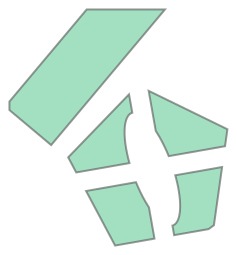

In [ ]:
from metashapes.metasurface import Metasurface
canv_new = Canvas(-Lx/2, -Ly/2, Lx, Ly, 300, 300)
shape_new = scale(shape, 2)
meta = Metasurface([shape_new], canv_new)
print(f'Spacing: {meta.spacing}, Lx: {meta.L[0]}, Ly: {meta.L[1]}, dx: {meta.pixel_size[0]}, dy: {meta.pixel_size[1]}')
meta.spacing = 25
print(f'Spacing: {meta.spacing}, Lx: {meta.L[0]}, Ly: {meta.L[1]}, dx: {meta.pixel_size[0]}, dy: {meta.pixel_size[1]}')
meta.unit_cell